# 1.2.Generate and write image patches from loaddata, to use for later image degradation generation.
This notebook:
1. Reads in the previously downloaded and processed loaddata file, as well as CellProfiler single cell level profiles.
2. Construct dataset & generate tiling patches, filter to keep only patches containing at least one CellProfiler object
3. Write normalized, patched images to disk keeping track of each image file and source metadata.

In [1]:
from pathlib import Path

import pyarrow.dataset as ds
from virtual_stain_flow.datasets.crop_dataset import CropImageDataset
from virtual_stain_flow.datasets.base_dataset import BaseImageDataset
from virtual_stain_flow.transforms.normalizations import MaxScaleNormalize
from virtual_stain_flow.datasets.ds_engine.crop_generators import generate_tile_crops
from virtual_stain_flow.evaluation.visualization import plot_dataset_grid

from utils.validate_config import (
    load_yaml_config,
    require_config_directory,
    require_config_membership,
    require_config_value,
)
from utils.loaddata_to_index import build_dataset_inputs
from utils.crop_dataset_interface import filter_crops_with_objects, get_crop_file_index
from utils.write_reference_image import write_reference_images

/home/weishanli/anaconda3/envs/vs-metric-analysis/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.1'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Pathing

In [2]:
config = load_yaml_config("degradation_config.yaml")
analysis_dir = require_config_directory(config, "analysis_out_dir", create=True)
local_profile_dir = require_config_directory(config, "local_profile_dir")
channels = require_config_value(config, "channels")
input_channel = require_config_membership(config, "input_channel", "channels")

metadata_download_path = Path("metadata")
metadata_download_path.mkdir(parents=True, exist_ok=True)

loaddata_dir = metadata_download_path / "loaddatas"
loaddata_files = sorted(path for path in loaddata_dir.glob("*.fixed.parquet"))
if not loaddata_files:
    raise FileNotFoundError(f"No processed loaddata Parquet files found in {loaddata_dir}.")

output_dir = analysis_dir / "patches" / "reference_records"
output_dir.mkdir(parents=True, exist_ok=True)

# Construct Dataset

Read in downloaded and processed loaddata

In [3]:
dataset = ds.dataset(loaddata_files, format="parquet")
table = dataset.to_table()
loaddata_df = table.to_pandas()
loaddata_df.head()

,FileName_OrigER,PathName_OrigER,FileName_OrigRNA,PathName_OrigRNA,FileName_OrigAGP,PathName_OrigAGP,FileName_OrigMito,PathName_OrigMito,FileName_OrigBrightfield,PathName_OrigBrightfield,...,Metadata_AbsPositionZ,Metadata_ChannelID,Metadata_Col,Metadata_FieldID,Metadata_PlaneID,Metadata_PositionX,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged
0,r03c03f01p01-ch2sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f01p01-ch6sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f01p01-ch3sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f01p01-ch4sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f01p01-ch1sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,0.134556,5,3,1,1,0.000000,0.000000,-0.000006,3,False
1,r03c03f02p01-ch2sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f02p01-ch6sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f02p01-ch3sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f02p01-ch4sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f02p01-ch1sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,0.134561,5,3,2,1,-0.000646,0.000646,-0.000006,3,False
2,r03c03f03p01-ch2sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f03p01-ch6sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f03p01-ch3sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f03p01-ch4sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f03p01-ch1sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,0.134558,5,3,3,1,0.000000,0.000646,-0.000006,3,False
3,r03c03f04p01-ch2sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f04p01-ch6sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f04p01-ch3sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f04p01-ch4sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f04p01-ch1sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,0.134554,5,3,4,1,0.000646,0.000646,-0.000006,3,False
4,r03c03f05p01-ch2sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f05p01-ch6sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f05p01-ch3sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f05p01-ch4sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,r03c03f05p01-ch1sk1fk1fl1.tiff,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,0.134553,5,3,5,1,0.000646,0.000000,-0.000006,3,False


Read in local profiles corresponding to the images indexed by loaddata.
We don't need the profiles here, just the metadata columns, which faciliates:
- merging with the loaddata to map image files to experimetnal conditions and image level identity.
- access of the object segmentation information, suggesting where in each image exists probable cells.   

In [4]:
profile_files = sorted(local_profile_dir.glob("*_sc_normalized.parquet"))
if not profile_files:
    raise FileNotFoundError(
        f"No normalized profile Parquet files found in {local_profile_dir}."
    )

print(f"Found {len(profile_files)} parquet files in {local_profile_dir}.")
profile_dataset = ds.dataset(profile_files, format="parquet")

fragments = list(profile_dataset.get_fragments())
shared_columns = set.intersection(
    *(set(fragment.physical_schema.names) for fragment in fragments)
)
shared_meta_columns = [
    column
    for column in profile_dataset.schema.names
    if column.startswith("Metadata_") and column in shared_columns
]
if not shared_meta_columns:
    raise ValueError("Profile Parquet files have no shared Metadata_ columns.")

profiles = profile_dataset.to_table(columns=shared_meta_columns).to_pandas()

profiles.head()

Found 6 parquet files in /mnt/data_nvme1/data/ALSF_pilot_data/preprocessed_profiles_SN0313537/single_cell_profiles.


,Metadata_cell_line,Metadata_row,Metadata_column,Metadata_seeding_density,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_time_point
0,DAOY,C,3,1000,619.796985,48.324623,629.552987,62.017799,57,2,BR00143976,C03,1,1,1,1,2,24
1,DAOY,C,3,1000,285.042751,51.796004,279.951864,56.588228,21,6,BR00143976,C03,1,1,1,1,6,24
2,DAOY,C,3,1000,873.971003,212.330721,876.508878,205.794360,23,9,BR00143976,C03,1,1,1,1,9,24
3,DAOY,C,3,1000,493.187623,36.985265,479.254866,45.496581,22,5,BR00143976,C03,1,1,2,2,5,24
4,DAOY,C,3,1000,862.834591,205.427162,866.557068,205.908787,6,7,BR00143976,C03,1,1,2,2,7,24


## Construct & showcase patched image dataset

Number of cropped images containing objects: 46289


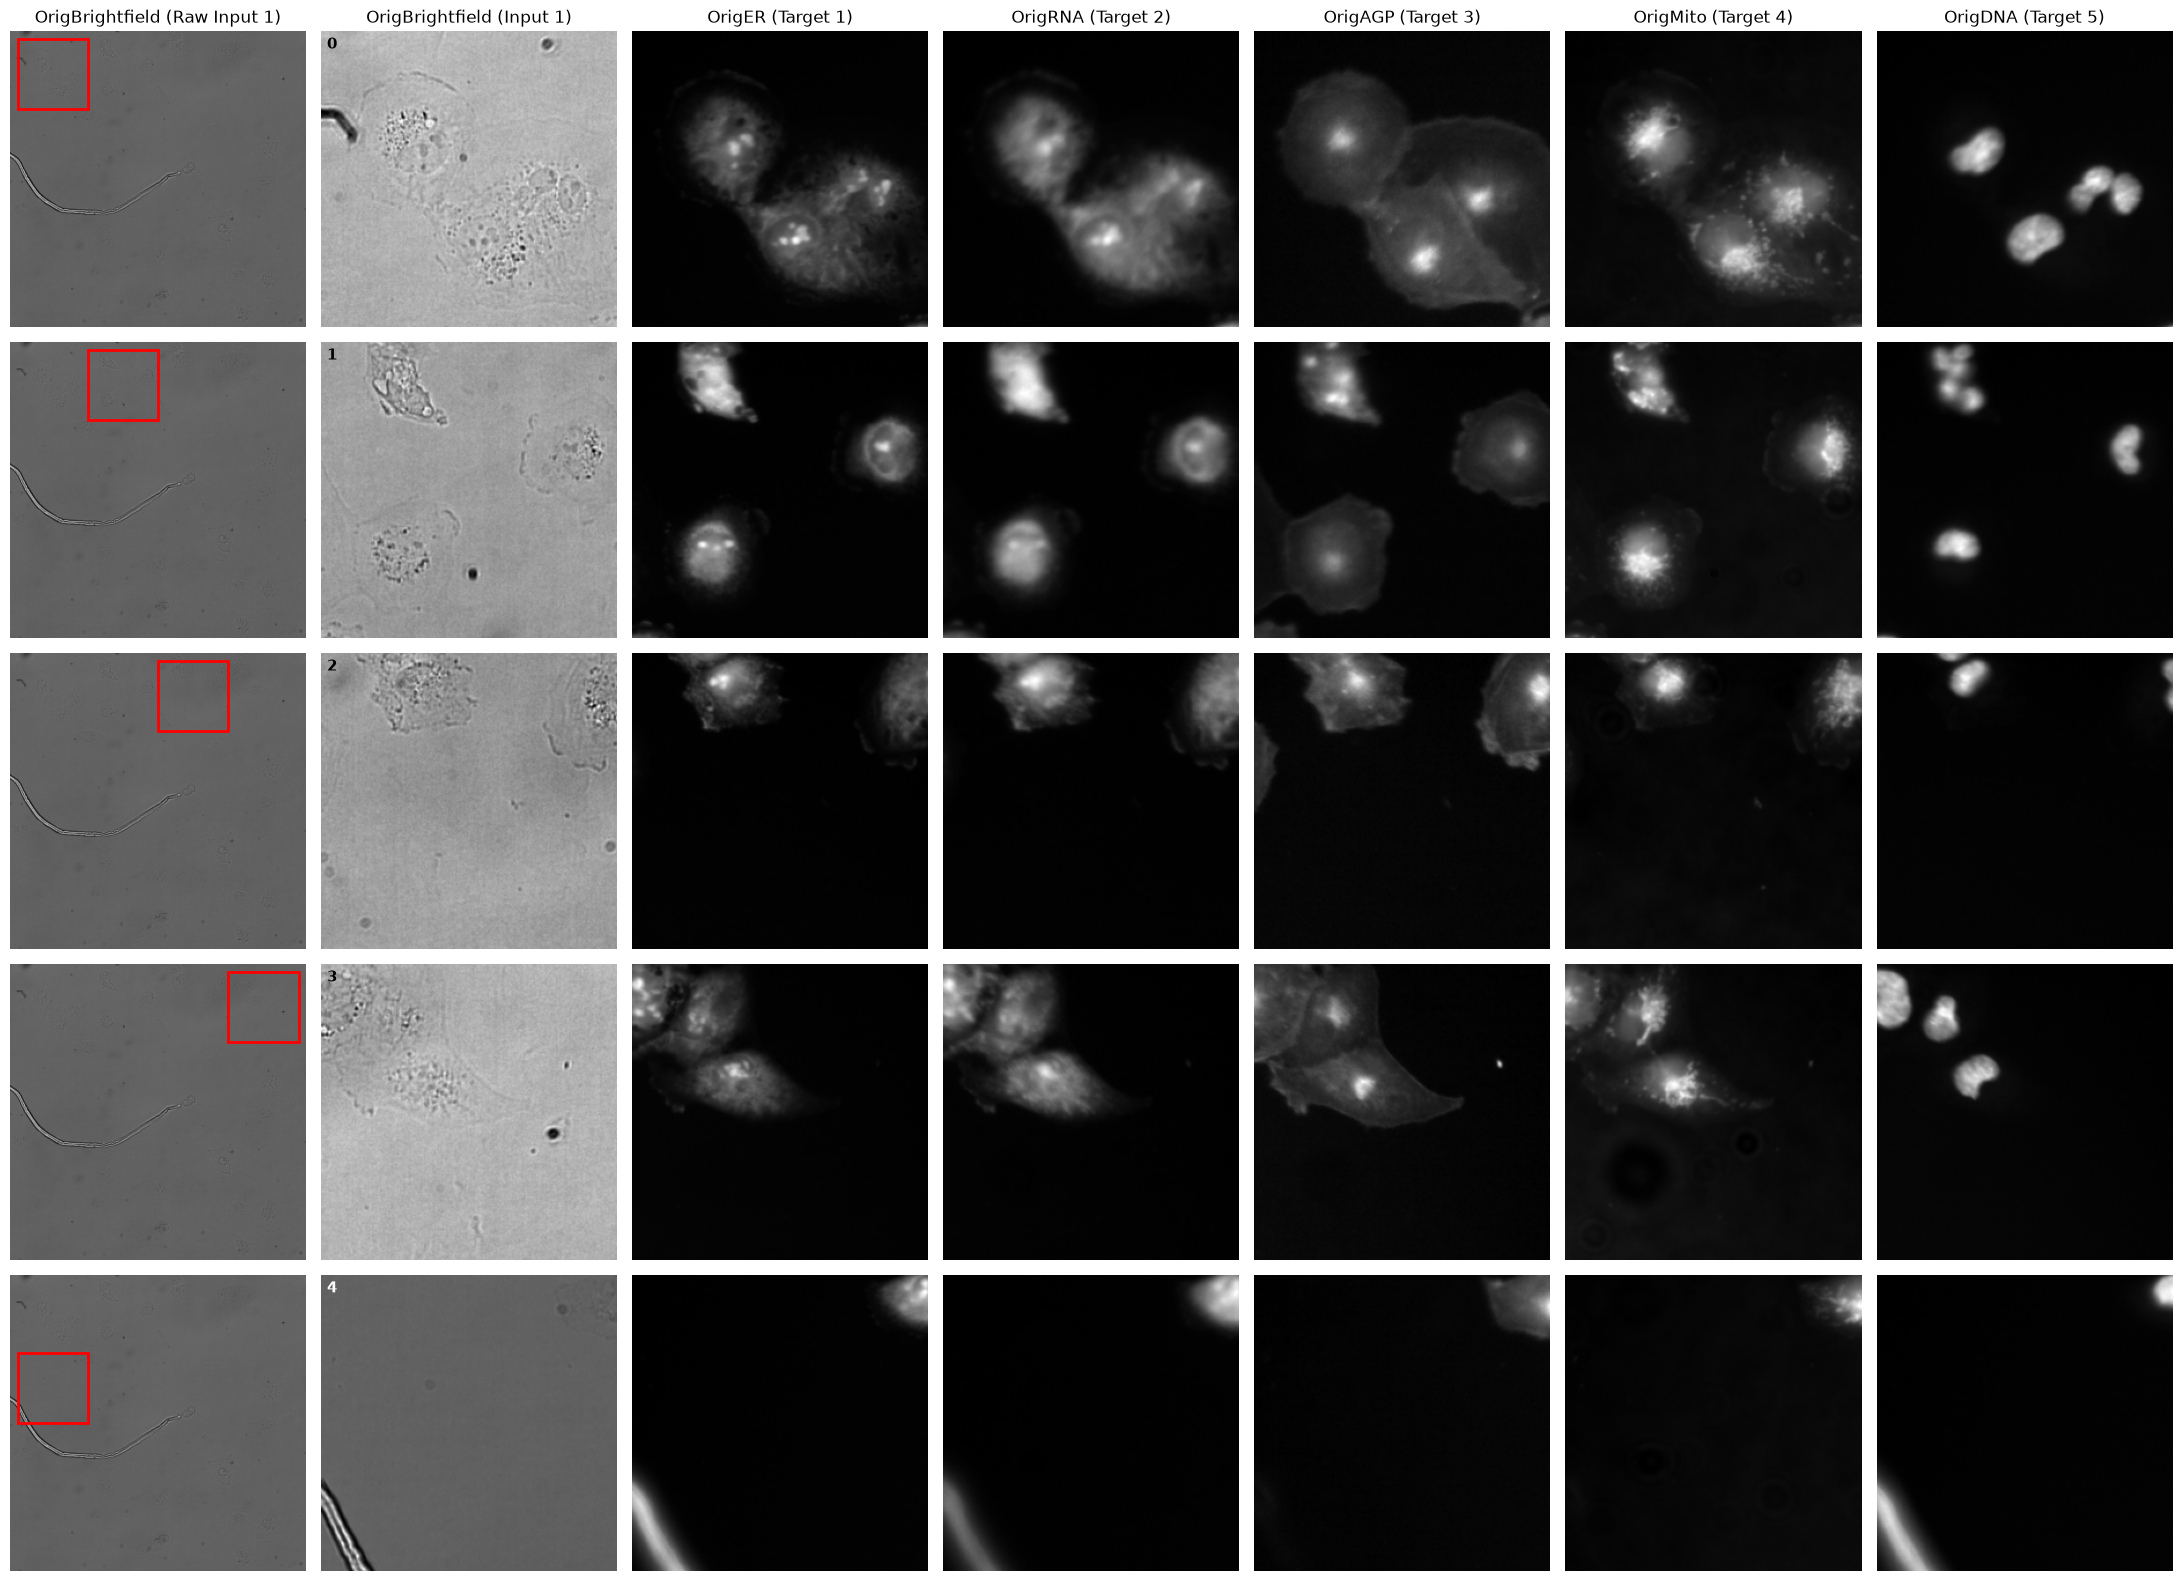

In [5]:
# Raw dataset returning multi-channel full FOVs
image_file_index_metadata, pt_mapping = build_dataset_inputs(
    loaddata=loaddata_df,
    profile=profiles,
    channels=channels,
)

dataset = BaseImageDataset(
    file_index=image_file_index_metadata.loc[:, channels],
    check_exists=True,
)

dataset.input_channel_keys = [input_channel]
dataset.target_channel_keys = [chan for chan in channels if chan != input_channel]

# Generate unguided tiling patches (crops)
crop_specs = generate_tile_crops(dataset, crop_size=256)
# Filter patches to only include those containing objects
crop_specs = filter_crops_with_objects(crop_specs, pt_mapping)
# Patch dataset containing only the "relevant" crops
cropped_dataset = CropImageDataset(
    file_index=dataset.file_index,
    transforms=MaxScaleNormalize("16bit"),
    crop_specs=crop_specs,
    pil_image_mode=dataset.pil_image_mode,
    input_channel_keys=dataset.input_channel_keys,
    target_channel_keys=dataset.target_channel_keys,
)

print(f"Number of cropped images containing objects: {len(cropped_dataset)}")
_ = plot_dataset_grid(
    cropped_dataset,
    indices=[0,1,2,3,4],
    wspace=0.025,
    hspace=0.05
)

## Index crops and preserve source-image provenance

Each crop manifest entry stores the positional row (`manifest_idx`) of its source multi-channel image. The next cell attaches crop geometry, source paths, and image-level metadata to a stable `crop_dataset_index`, validates the source paths against `cropped_dataset.file_index`, and writes a typed `crop_index.parquet` audit table.

In [6]:
crop_index = get_crop_file_index(
    cropped_dataset,
    image_file_index_metadata,
)

# Validate no source-file mismatches between the crop index and original metadata.
source_rows = crop_index["source_image_row"]
dataset_source_files = image_file_index_metadata.loc[source_rows].reset_index(drop=True)
for channel in channels:
    if not dataset_source_files[channel].astype(str).equals(
        crop_index[channel].astype(str)
    ):
        raise ValueError(f"Source-file mismatch for channel {channel}.")
    crop_index[channel] = crop_index[channel].astype(str)

print(f"Indexed {len(crop_index):,} crops")
crop_index.rename(columns={"crop_dataset_index": "dataset_index"}, inplace=True)
crop_index.head()

Indexed 46,289 crops


,dataset_index,source_image_row,x,y,width,height,source_image_index,OrigER,OrigRNA,OrigAGP,...,Metadata_ChannelID,Metadata_Col,Metadata_FieldID,Metadata_PlaneID,Metadata_PositionX,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged,_iloc1
0,0,0,28,28,256,256,0,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,5,3,2,1,-0.000646,0.000646,-0.000006,3,False,0
1,1,0,284,28,256,256,0,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,5,3,2,1,-0.000646,0.000646,-0.000006,3,False,0
2,2,0,540,28,256,256,0,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,5,3,2,1,-0.000646,0.000646,-0.000006,3,False,0
3,3,0,796,28,256,256,0,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,5,3,2,1,-0.000646,0.000646,-0.000006,3,False,0
4,4,0,28,284,256,256,0,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,...,5,3,2,1,-0.000646,0.000646,-0.000006,3,False,0


## Write normalized channel patches as embedded Parquet records

The writer stores one self-describing row per crop/channel under `reference_records/`. Each row contains a stable `record_id`, the normalized float32 `YX` pixel buffer, its shape and dtype contract, source-image provenance, crop geometry, and all image-level metadata. Bounded Parquet shards are written through validated temporary files and valid completed shards are reused on rerun. Reference and future degraded-stack datasets use the same record envelope and map through the same `record_id`.

In [7]:
write_reference_images(
    path=output_dir,
    dataset=cropped_dataset,
    metadata=crop_index,
)

Writing reference images to parquet:   0%|          | 0/46289 [00:00<?, ?it/s]